# Лабораторная работа № 6: ARIMA 2

### Капанадзе Давид

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

In [3]:
df = pd.read_csv('/Users/d.kapanadze/Downloads/Учеба/ИТМО/2 семестр/Анализ данных на python/lect_forecast_06_ARIMA_lab/З†§†з®_§Ђп_Ђ†°Ѓа†вЃа≠Ѓ©_ARIMA_1/M3_152_0.csv',
        header=None)
df = df.drop(columns=0)

df.shape

(38, 1)

In [4]:
df.head()

,1
0,5717.0
1,6374.0
2,5837.5
3,7318.4
4,4613.0


<Axes: >

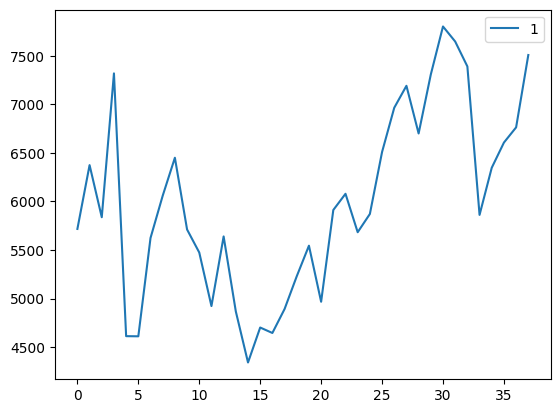

In [5]:
df.plot()

### Ряд не стационарный $\Rightarrow$ d = 1/2

<Axes: >

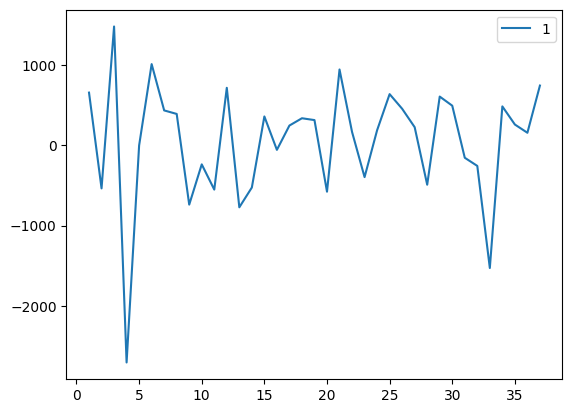

In [6]:
df_d1 = df.diff()

df_d1.plot()

### Тренд пропал, но дисперсия не постоянна

<Axes: >

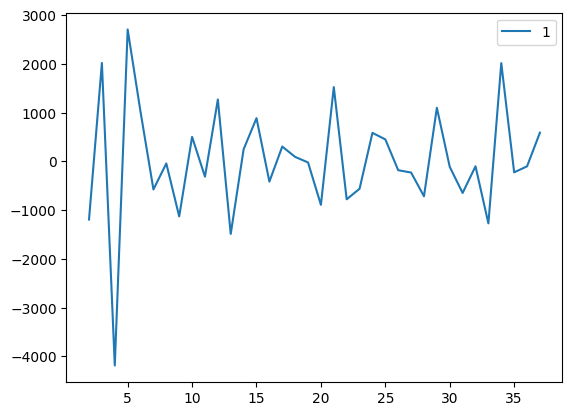

In [7]:
df_d2 = df_d1.diff()

df_d2.plot()

### Дальше дифференцированием ряда ничего не добъемся $\Rightarrow$ d =1 

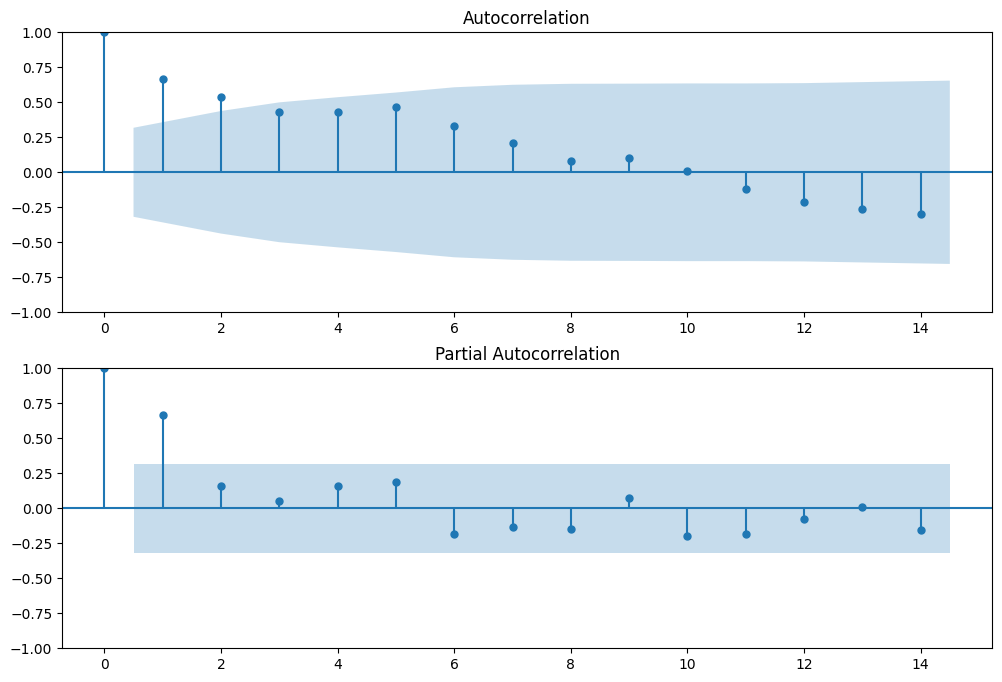

In [8]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(df, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(df, method='ywmle', lags=14, ax=plt.gca())
plt.show()

#### По граффику pacf видно что p = 2 (резкий обрыв и далее лаг в пределах синей зоны)

#### А по графику acf: q = 8 (резкий обрыв)

/Users/d.kapanadze/Downloads/Учеба/ИТМО/2 семестр/Анализ данных на python/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


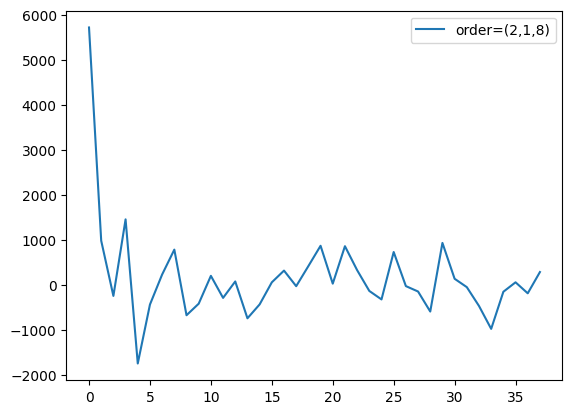

In [9]:
model = ARIMA(df, order=(2,1,8))
model = model.fit()

residual = model.resid
residual.plot(label='order=(2,1,8)')
plt.legend()

In [10]:
model = ARIMA(df.head(30), order=(2,1,8))
model = model.fit()

/Users/d.kapanadze/Downloads/Учеба/ИТМО/2 семестр/Анализ данных на python/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/d.kapanadze/Downloads/Учеба/ИТМО/2 семестр/Анализ данных на python/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [11]:
pred = model.predict(0)

for j in range(30, 38):
    pred = pd.concat([pred, model.predict(j)])

df_pred = pd.DataFrame(pred)
df_pred = df_pred.drop(0).reset_index(drop=True)

In [12]:
from sklearn.metrics import mean_absolute_error

y_pred = df_pred.iloc[30:38]
y_test = df.iloc[30:37]


print('Стандартное отклонение ряда:', df.std().iloc[0])
print('Ошибка на тестовом множестве:', mean_absolute_error(y_test, y_pred))

Стандартное отклонение ряда: 967.8951237411405
Ошибка на тестовом множестве: 607.0368924437818


In [13]:
model = ARIMA(df, order=(2,1,8))
model = model.fit()

pred = model.predict(0)

for j in range(38, 42):
    pred = pd.concat([pred, model.predict(j)])

df_pred = pd.DataFrame(pred)
df_pred = df_pred.drop(0).reset_index(drop=True)

/Users/d.kapanadze/Downloads/Учеба/ИТМО/2 семестр/Анализ данных на python/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Text(0.5, 1.0, 'Предсказание на 4 года вперед')

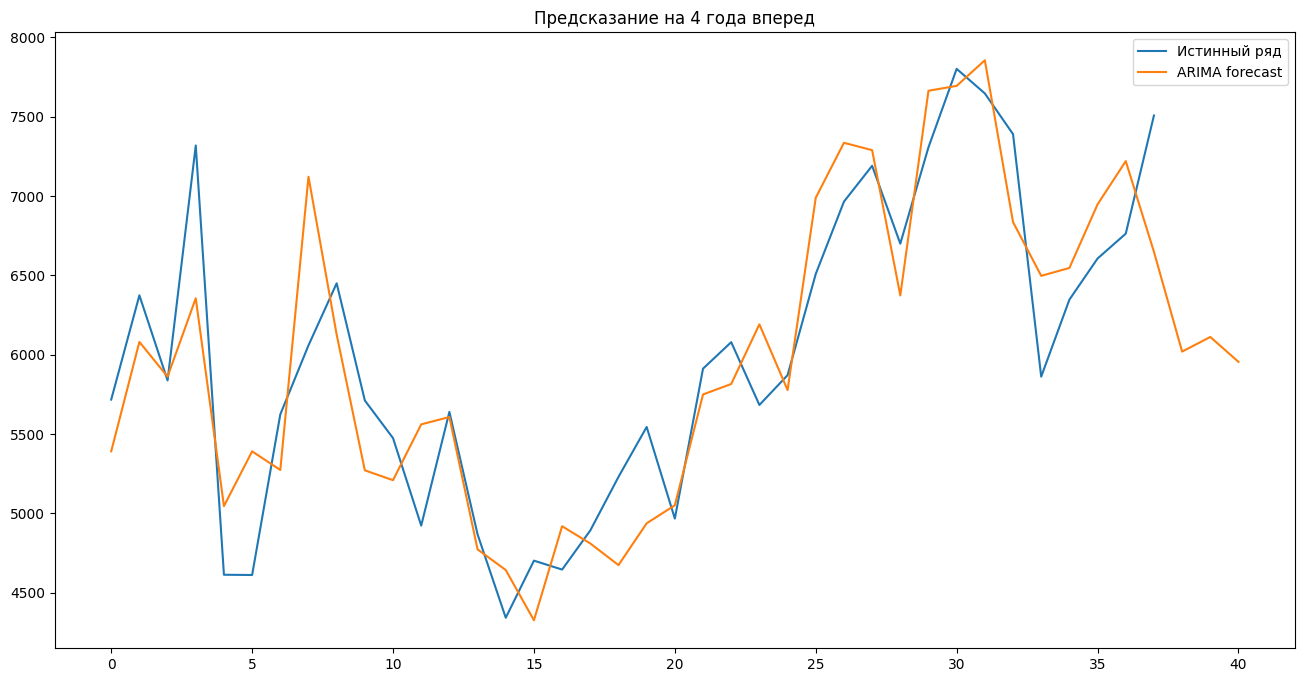

In [14]:
plt.figure(figsize=(16,8))
plt.plot(df, label='Истинный ряд')
plt.plot(df_pred, label='ARIMA forecast')
plt.legend(loc='best')
plt.title("Предсказание на 4 года вперед")

----

### Попробуем автоматический подбор параметров

In [36]:
from pmdarima import auto_arima

model = auto_arima(
    df,
    seasonal=False,
    test='adf',
    information_criterion='aic',
    stepwise=True,
    start_p=0, start_q=0,
    max_p=5, max_d=2, max_q=5
)

model.predict(n_periods=4)

38    7507.4
39    7507.4
40    7507.4
41    7507.4
dtype: float64